In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [2]:
def burgers_1d_frames(J, N):
    os.chdir('/Users/evandaniels/Research/CentPackL/simulation_burgers_SD2')
    os.makedirs('u_frames', exist_ok=True)
    
    x_files = sorted(glob.glob('mesh_files/x_p*'))
    x = np.concatenate([np.loadtxt(f) for f in x_files])
    
    for n in range(N):
        u_files = sorted(glob.glob(f'u_files/u_p*_{n:03d}'))
        u = np.concatenate([np.loadtxt(f) for f in u_files])
        
        plt.figure()
        plt.plot(x, u, '.-')
        plt.axis([0.0, 1, -0.8, 1.5])
        plt.savefig(f'u_frames/u_{n:03d}.png', dpi=72)
        plt.close()

burgers_1d_frames(J=256, N=52)

ValueError: need at least one array to concatenate

In [3]:
from PIL import Image
import glob

frames = [Image.open(f) for f in sorted(glob.glob('u_frames/*.png'))]
frames[0].save('Burgers_1d_SD2.gif', save_all=True, append_images=frames[1:], duration=100, loop=0)

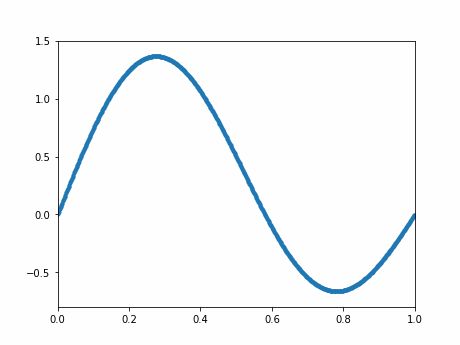

In [4]:
from IPython.display import Image as IPImage
IPImage('Burgers_1d_SD2.gif')